<a href="https://colab.research.google.com/github/AtulSomkuwar/Predictive-Modeling-for-Graduate-Admission/blob/main/ML_Team_25_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression Models

## Linear Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

===== Linear Regression =====
R² Score: 0.8188
MAE: 0.0427
MSE: 0.0037
RMSE: 0.0609
Cross-validation R² Scores: [0.82416586 0.72346539 0.8216056  0.78997697 0.88029422]
Average CV R²: 0.8079



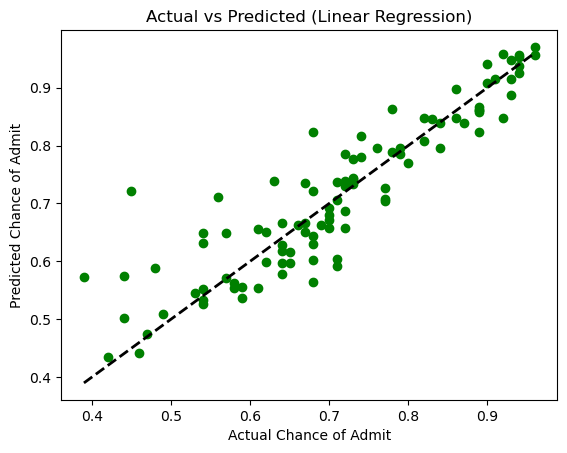

===== Ridge Regression =====
R² Score: 0.8188
===== Lasso Regression =====
R² Score: 0.2670


In [ ]:
jm_data = pd.read_csv('dataset.csv')
jm_data

X = jm_data.iloc[:, 1:-1].values
y = jm_data.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

mse_lin = mean_squared_error(y_test, y_pred_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("===== Linear Regression =====")
print(f"R² Score: {r2_lin:.4f}")
print(f"MAE: {mae_lin:.4f}")
print(f"MSE: {mse_lin:.4f}")
print(f"RMSE: {rmse_lin:.4f}")

# Cross-validation (5 folds)
cv_scores = cross_val_score(lin_model, X_train, y_train, cv=5, scoring='r2')
print(f"Cross-validation R² Scores: {cv_scores}")
print(f"Average CV R²: {cv_scores.mean():.4f}\n")

# Plot Actual vs Predicted (Linear Regression)
plt.scatter(y_test, y_pred_lin, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted (Linear Regression)')
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.show()

# Ridge regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)
print("===== Ridge Regression =====")
print(f"R² Score: {r2_ridge:.4f}")


# Lasso Regression (L1 Regularization)

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

r2_lasso = r2_score(y_test, y_pred_lasso)
print("===== Lasso Regression =====")
print(f"R² Score: {r2_lasso:.4f}")

# Compare all models visually
models = ['Linear', 'Ridge', 'Lasso']
r2_scores = [r2_lin, r2_ridge, r2_lasso]

## Polynomial Regression

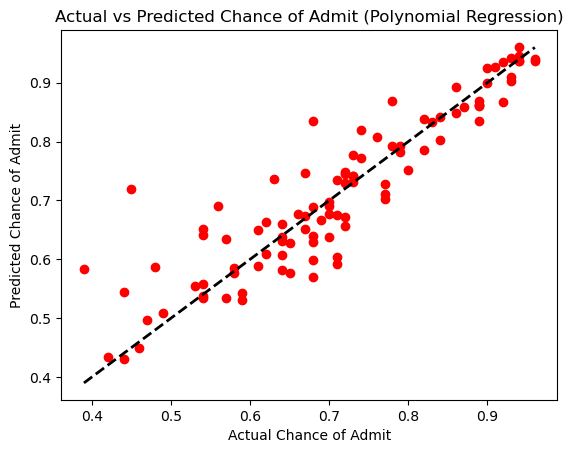

===== Polynomial Regression (Degree = 2) =====
R² Score: 0.8265
Mean Absolute Error: 0.0406
Mean Squared Error: 0.0035
Root Mean Squared Error: 0.0596

Predicted Chance of Admit for input data: 0.6402897834777832


In [ ]:
X = jm_data.iloc[:, 1:-1].values
y = jm_data.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

poly_reg = PolynomialFeatures(degree=2)
X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly = poly_reg.transform(X_test)

lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_train_poly, y_train)

# Predict on test data
y_pred_poly = lin_reg_2.predict(X_test_poly)

# Plot Actual vs Predicted
plt.scatter(y_test, y_pred_poly, color='red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted Chance of Admit (Polynomial Regression)')
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.show()

# Evaluate Polynomial Regression
mse = mean_squared_error(y_test, y_pred_poly)
mae = mean_absolute_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
r2_poly = r2_score(y_test, y_pred_poly)

print("===== Polynomial Regression (Degree = 2) =====")
print(f"R² Score: {r2_poly:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")


input_data = [[301, 99, 3, 2.5, 2, 8.45, 1]]

# Scale input data
input_scaled = sc.transform(input_data)

# Transform with the fitted polynomial transformer
input_poly = poly_reg.transform(input_scaled)

# Predict the output
predicted_value = lin_reg_2.predict(input_poly)
print("\nPredicted Chance of Admit for input data:", predicted_value[0])

### Regularization Lasso & Ridge with MAE,MSE,R2 Score

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# Ridge Regression
ridge_poly = Ridge(alpha=1.0)
ridge_poly.fit(X_train_poly, y_train)
y_pred_ridge = ridge_poly.predict(X_test_poly)

print("===== Ridge Regression (Degree = 2, α=1.0) =====")
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
print(f"MSE: {mse_ridge:.4f}")

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
print(f"MAE: {mae_ridge:.4f}")

rmse_ridge = np.sqrt(mse_ridge)
print(f"RMSE: {rmse_ridge:.4f}\n")
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"R² Score: {r2_ridge:.4f}")

# Lasso Regression
lasso_poly = Lasso(alpha=0.001, max_iter=10000)
lasso_poly.fit(X_train_poly, y_train)
y_pred_lasso = lasso_poly.predict(X_test_poly)

print("===== Lasso Regression (Degree = 1, α=0.001) =====")
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print(f"MSE: {mse_lasso:.4f}")

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
print(f"MAE: {mae_lasso:.4f}")

rmse_lasso = np.sqrt(mse_lasso)
print(f"RMSE: {rmse_lasso:.4f}")

r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"R² Score: {r2_lasso:.4f}")

===== Ridge Regression (Degree = 2, α=1.0) =====
MSE: 0.0036
MAE: 0.0407
RMSE: 0.0596

R² Score: 0.8261
===== Lasso Regression (Degree = 2, α=0.001) =====
MSE: 0.0036
MAE: 0.0409
RMSE: 0.0598
R² Score: 0.8253


## Cross-validation (5 folds) for Polynomial Regression

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

# Define K-Fold cross-validation (e.g., 5 folds)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lin_reg_2, X_train_poly, y_train, cv=kfold, scoring='r2')

print("\n===== Cross-Validation (Polynomial Regression) =====")
print("R² Scores for each fold:", np.round(cv_scores, 4))
print(f"Average R² Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation of R²: {cv_scores.std():.4f}")


===== Cross-Validation (Polynomial Regression) =====
R² Scores for each fold: [0.7813 0.7882 0.7216 0.8268 0.8757]
Average R² Score: 0.7987
Standard Deviation of R²: 0.0512


Degree: 1
R² Score: 0.8188
MAE: 0.0427
MSE: 0.0037
RMSE: 0.0609

Degree: 2
R² Score: 0.8265
MAE: 0.0406
MSE: 0.0035
RMSE: 0.0596

Degree: 3
R² Score: 0.6443
MAE: 0.0605
MSE: 0.0073
RMSE: 0.0853

Degree: 4
R² Score: -10.9376
MAE: 0.2451
MSE: 0.2441
RMSE: 0.4941

Degree: 5
R² Score: -30.2237
MAE: 0.4220
MSE: 0.6385
RMSE: 0.7991



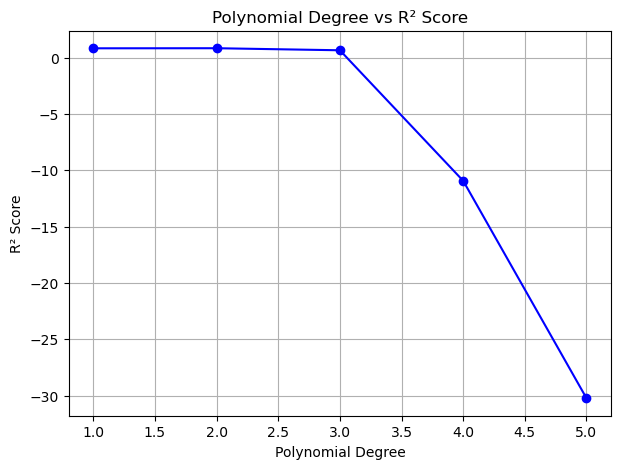

Best Degree Based on R²: 2


In [ ]:
degrees = [1, 2, 3, 4, 5]
r2_scores = []

for d in degrees:
    # Create polynomial features
    poly_reg = PolynomialFeatures(degree=d)
    X_train_poly = poly_reg.fit_transform(X_train)
    X_test_poly = poly_reg.transform(X_test)

    # Train model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test_poly)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)

    # Print results for this degree
    print(f"Degree: {d}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}\n")

# Plot R² vs Degree
plt.figure(figsize=(7,5))
plt.plot(degrees, r2_scores, marker='o', color='blue')
plt.title('Polynomial Degree vs R² Score')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.grid(True)
plt.show()


best_degree = degrees[np.argmax(r2_scores)]
print(f"Best Degree Based on R²: {best_degree}")

# Classification Models

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("dataset.csv")

In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (500, 9)


In [ ]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [ ]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


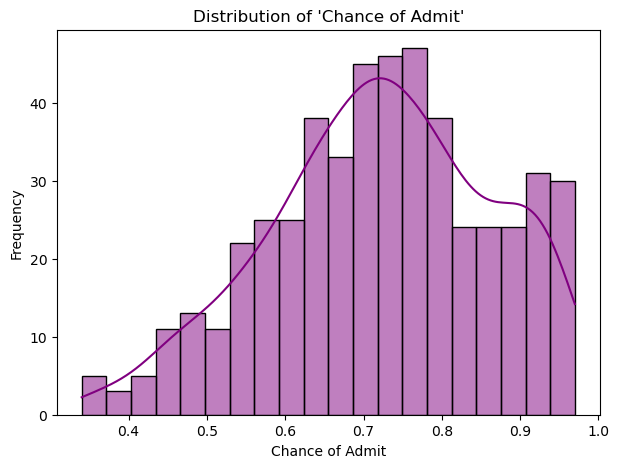

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df['Chance of Admit '], kde=True, bins=20, color='purple')
plt.title("Distribution of 'Chance of Admit'")
plt.xlabel("Chance of Admit")
plt.ylabel("Frequency")
plt.show()

In [ ]:
y = df["Chance of Admit "]

In [ ]:
thresholds=[0.5, 0.7, 0.75, 0.8]

In [ ]:
class_stats = {}

for t in thresholds:
    counts = y.ge(t).value_counts().rename({True: "Admit", False: "Reject"})
    total = counts.sum()
    percents = (counts / total * 100).round(2)
    class_stats[t] = {
        "Admit (count)": counts.get("Admit", 0),
        "Reject (count)": counts.get("Reject", 0),
        "Admit (%)": percents.get("Admit", 0),
        "Reject (%)": percents.get("Reject", 0),
    }

In [ ]:
summary_df = pd.DataFrame(class_stats).T
summary_df.index.name = "Threshold"

In [ ]:
print("\nClass balance by threshold:")
display(summary_df)


Class balance by threshold:


,Admit (count),Reject (count),Admit (%),Reject (%)
Threshold,,,,
0.50,463.0,37.0,92.6,7.4
0.70,300.0,200.0,60.0,40.0
0.75,218.0,282.0,43.6,56.4
0.80,155.0,345.0,31.0,69.0


#### We choose the threshold to be 0.75 as it provides the most balanced split of the dataset with approximately 43.6% students classified as admitted and 56.4% as not admitted. This balance helps prevent bias toward one class during model training.

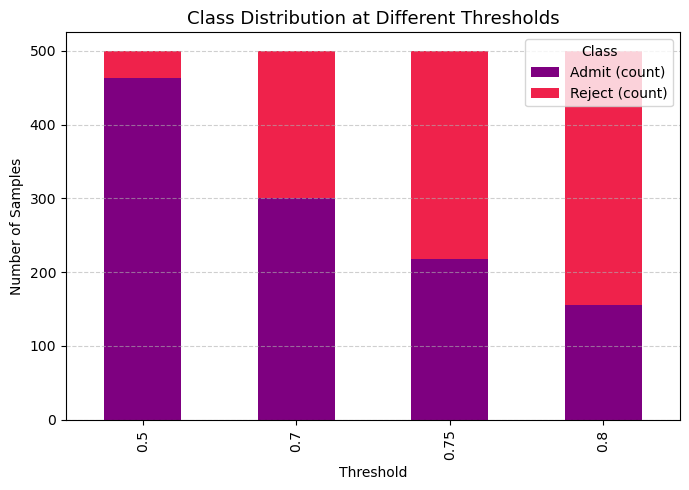

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = summary_df[["Admit (count)", "Reject (count)"]].plot(
    kind="bar", stacked=True, color=["#7E0080", "#EF224B"], ax=ax
)

plt.title("Class Distribution at Different Thresholds", fontsize=13)
plt.xlabel("Threshold")
plt.ylabel("Number of Samples")
plt.legend(title="Class")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
df['Admit_Status'] = (df['Chance of Admit '] >= 0.75).astype(int)

In [ ]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,Admit_Status
0,1,337,118,4,4.5,4.5,9.65,1,0.92,1
1,2,324,107,4,4.0,4.5,8.87,1,0.76,1
2,3,316,104,3,3.0,3.5,8.00,1,0.72,0
3,4,322,110,3,3.5,2.5,8.67,1,0.80,1
4,5,314,103,2,2.0,3.0,8.21,0,0.65,0


### Choosing Best Train/Test Split

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(columns=["Serial No.", "Chance of Admit ", "Admit_Status"])
y = df["Admit_Status"]

In [ ]:
split_ratios = [0.6, 0.7, 0.8, 0.9]
results = []

for ratio in split_ratios:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=1 - ratio, random_state=42, stratify=y
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    train_mce = 1 - train_acc
    test_mce = 1 - test_acc

    results.append({
        "Train Ratio": ratio,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Train MCE": train_mce,
        "Test MCE": test_mce,
    })

split_df = pd.DataFrame(results)
display(split_df)

,Train Ratio,Train Accuracy,Test Accuracy,Train MCE,Test MCE
0,0.6,0.886667,0.880000,0.113333,0.120000
1,0.7,0.876791,0.907285,0.123209,0.092715
2,0.8,0.880000,0.910000,0.120000,0.090000
3,0.9,0.880000,0.980000,0.120000,0.020000


#### From the above table, we can see that for train:test ratio of 0.6:0.4, both the MCEs are close but relatively high. With train:test ratio of 0.7:0.3, we notice that the train MCE is high but the test MCE is lower which is satisfiable but with the split of 0.8:0.2,

### Therefore from here on we will take the train-test split as 0.9:0.1

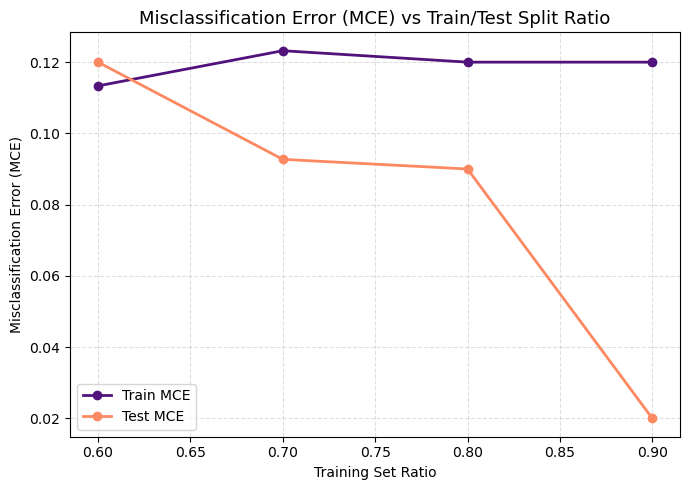

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(7, 5))
colors = [cm.magma(0.25), cm.magma(0.75)]

ax.plot(split_df["Train Ratio"], split_df["Train MCE"],
        marker="o", color=colors[0], label="Train MCE", linewidth=2)

ax.plot(split_df["Train Ratio"], split_df["Test MCE"],
        marker="o", color=colors[1], label="Test MCE", linewidth=2)

plt.title("Misclassification Error (MCE) vs Train/Test Split Ratio", fontsize=13)
plt.xlabel("Training Set Ratio")
plt.ylabel("Misclassification Error (MCE)")
plt.legend()
plt.grid(alpha=0.4, linestyle="--")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegression(max_iter=1000)

cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

print("Cross Validation Accuracies for each fold:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores).round(4))
print("Standard Deviation:", np.std(cv_scores).round(4))


Cross Validation Accuracies for each fold: [0.89 0.8  0.9  0.88 0.93]
Mean CV Accuracy: 0.88
Standard Deviation: 0.0434


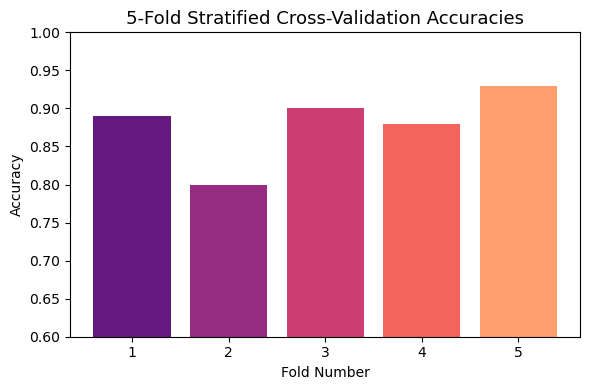

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, 6), cv_scores, color=cm.magma(np.linspace(0.3, 0.8, 5)))
plt.title("5-Fold Stratified Cross-Validation Accuracies", fontsize=13)
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.ylim(0.6, 1.0)
plt.tight_layout()
plt.show()

## Cross Validation vs Hold Out

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

holdout_acc = accuracy_score(y_test, y_pred)
holdout_mce = 1 - holdout_acc

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

cv_mean_acc = np.mean(cv_scores)
cv_std_acc = np.std(cv_scores)
cv_mean_mce = 1 - cv_mean_acc
cv_std_mce = np.std(1 - cv_scores)

comparison_df = pd.DataFrame({
    "Method": ["Hold-Out (80/20)", "5-Fold CV"],
    "Mean Accuracy": [holdout_acc, cv_mean_acc],
    "Std Accuracy": [0, cv_std_acc],
    "Mean MCE": [holdout_mce, cv_mean_mce],
    "Std MCE": [0, cv_std_mce]
})

display(comparison_df)

,Method,Mean Accuracy,Std Accuracy,Mean MCE,Std MCE
0,Hold-Out (80/20),0.91,0.000000,0.09,0.000000
1,5-Fold CV,0.88,0.043359,0.12,0.043359


Based on the Bias–Variance of Hold-Out, we selected the 90:10 train–test split as it provides a good balance between bias and variance for the hold-out method.
However, since our dataset is relatively small, and to obtain a more reliable estimate of model performance, we further use 5-Fold Stratified Cross-Validation for all subsequent model evaluations.
This allows us to average results across multiple training and test partitions, minimizing variance while maintaining low bias.

## Classification Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(reg_param=0.1)
}

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

holdout_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    mce = 1 - acc
    holdout_results.append([name, acc, mce])

holdout_df = pd.DataFrame(holdout_results, columns=["Model", "Hold-Out Accuracy", "Hold-Out MCE"])
display(holdout_df)

,Model,Hold-Out Accuracy,Hold-Out MCE
0,Logistic Regression,0.98,0.02
1,KNN,0.88,0.12
2,SVM,0.90,0.10
3,Decision Tree,0.92,0.08
4,Random Forest,0.96,0.04
5,Naive Bayes,0.96,0.04
6,Quadratic Discriminant Analysis,0.96,0.04


In [ ]:
cv_results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    acc_mean = np.mean(scores)
    acc_std = np.std(scores)
    mce_mean = 1 - acc_mean
    mce_std = np.std(1 - scores)
    cv_results.append([name, acc_mean, acc_std, mce_mean, mce_std])

cv_df = pd.DataFrame(cv_results, columns=["Model", "CV Mean Accuracy", "CV Std", "CV Mean MCE", "CV MCE Std"])
display(cv_df)

,Model,CV Mean Accuracy,CV Std,CV Mean MCE,CV MCE Std
0,Logistic Regression,0.880,0.043359,0.120,0.043359
1,KNN,0.858,0.016000,0.142,0.016000
2,SVM,0.868,0.011662,0.132,0.011662
3,Decision Tree,0.858,0.020396,0.142,0.020396
4,Random Forest,0.866,0.013565,0.134,0.013565
5,Naive Bayes,0.868,0.011662,0.132,0.011662
6,Quadratic Discriminant Analysis,0.864,0.016248,0.136,0.016248


In [ ]:
comparison_df = holdout_df.merge(cv_df, on="Model")
display(comparison_df)

,Model,Hold-Out Accuracy,Hold-Out MCE,CV Mean Accuracy,CV Std,CV Mean MCE,CV MCE Std
0,Logistic Regression,0.98,0.02,0.880,0.043359,0.120,0.043359
1,KNN,0.88,0.12,0.858,0.016000,0.142,0.016000
2,SVM,0.90,0.10,0.868,0.011662,0.132,0.011662
3,Decision Tree,0.92,0.08,0.858,0.020396,0.142,0.020396
4,Random Forest,0.96,0.04,0.866,0.013565,0.134,0.013565
5,Naive Bayes,0.96,0.04,0.868,0.011662,0.132,0.011662
6,Quadratic Discriminant Analysis,0.96,0.04,0.864,0.016248,0.136,0.016248


### Observations
- Hold-out accuracies are slightly higher due to optimistic bias a single “lucky” test split can make the model seem better than it truly is.
- Cross-validation accuracies are slightly lower because averaging across multiple folds reduces bias but introduces a mild pessimistic bias, giving a more reliable performance estimate.

## Logistic Regression From Scratch

In [ ]:
class MyLogisticRegression:
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0

        for _ in range(self.n_iters):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)

            dw = (1 / m) * np.dot(X.T, (y_predicted - y))
            db = (1 / m) * np.sum(y_predicted - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
        return np.where(y_predicted >= 0.5, 1, 0)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.1, random_state=42, stratify=y
)

my_lr = MyLogisticRegression(lr=0.01, n_iters=2000)
my_lr.fit(X_train, y_train)

y_pred_train = my_lr.predict(X_train)
y_pred_test = my_lr.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
train_mce = 1 - train_acc
test_mce = 1 - test_acc

print(f"Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")
print(f"Train MCE: {train_mce:.4f} | Test MCE: {test_mce:.4f}")

Train Accuracy: 0.8689 | Test Accuracy: 0.9600
Train MCE: 0.1311 | Test MCE: 0.0400


In [ ]:
scratch_results = pd.DataFrame({
    "Model": ["Logistic Regression (Scratch)"],
    "Hold-Out Accuracy": [test_acc],
    "Hold-Out MCE": [1 - test_acc],
    "CV Mean Accuracy": [np.nan],
    "CV Std": [np.nan],
    "CV Mean MCE": [np.nan],
    "CV MCE Std": [np.nan]
})

final_df = pd.concat([comparison_df, scratch_results], ignore_index=True)
display(final_df)

,Model,Hold-Out Accuracy,Hold-Out MCE,CV Mean Accuracy,CV Std,CV Mean MCE,CV MCE Std
0,Logistic Regression,0.98,0.02,0.880,0.043359,0.120,0.043359
1,KNN,0.88,0.12,0.858,0.016000,0.142,0.016000
2,SVM,0.90,0.10,0.868,0.011662,0.132,0.011662
3,Decision Tree,0.92,0.08,0.858,0.020396,0.142,0.020396
4,Random Forest,0.96,0.04,0.866,0.013565,0.134,0.013565
5,Naive Bayes,0.96,0.04,0.868,0.011662,0.132,0.011662
6,Quadratic Discriminant Analysis,0.96,0.04,0.864,0.016248,0.136,0.016248
7,Logistic Regression (Scratch),0.96,0.04,NaN,NaN,NaN,NaN


## K Nearest Neighbours From Scratch

In [ ]:
jm_data = pd.read_csv("dataset.csv")

X = jm_data.iloc[:, 1:-1].values
y = jm_data.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=2)

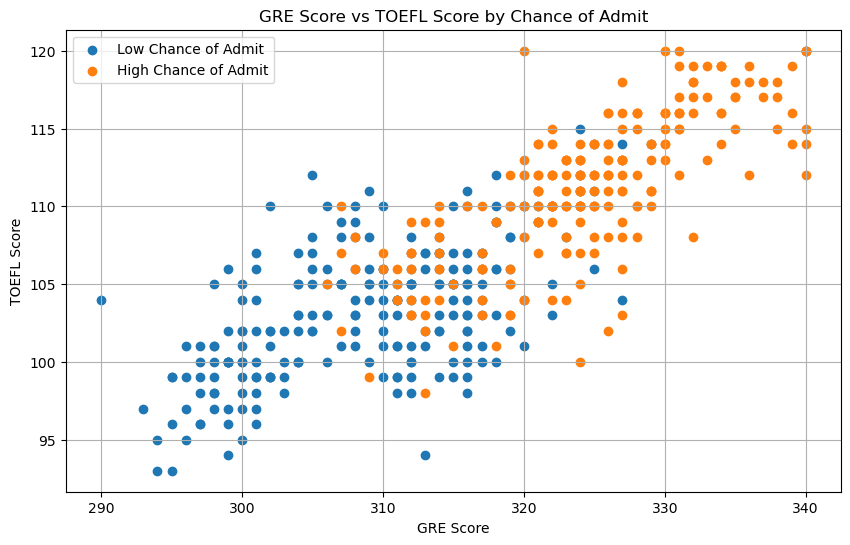

In [ ]:
# Calculate the median of y_train to create two categories
y_median = np.median(y_train)

y_train_class = np.where(y_train > y_median, 1, 0)
y_test_class = np.where(y_test > y_median, 1, 0)


# Visualize GRE vs TOEFL based on admit chance
plt.figure(figsize=(10, 6))
plt.scatter(X_train[y_train_class == 0, 0], X_train[y_train_class == 0, 1],
            color='tab:blue', label='Low Chance of Admit')
plt.scatter(X_train[y_train_class == 1, 0], X_train[y_train_class == 1, 1],
            color='tab:orange', label='High Chance of Admit')
plt.xlabel('GRE Score')
plt.ylabel('TOEFL Score')
plt.title('GRE Score vs TOEFL Score by Chance of Admit')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((b - a) ** 2))

In [ ]:
# KNN Class Implementation
class KNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        # Compute distances
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
        # Get k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        # Majority vote
        most_common = Counter(k_nearest_labels).most_common(1)[0][0]
        return most_common

In [ ]:
def find_best_k(X_train, X_test, y_train, y_test, k_values):
    accuracies = []
    for k in k_values:
        knn = KNN(k)
        knn.fit(X_train, y_train)
        predictions = knn.predict(X_test)
        acc = np.mean(predictions == y_test) * 100
        accuracies.append(acc)
        print(f"k = {k}: Accuracy = {acc:.2f}%")
    return accuracies

k_values = range(1, 21)
accuracies = find_best_k(X_train_scaled, X_test_scaled, y_train_class, y_test_class, k_values)

k = 1: Accuracy = 82.00%
k = 2: Accuracy = 82.00%
k = 3: Accuracy = 82.00%
k = 4: Accuracy = 86.00%
k = 5: Accuracy = 86.00%
k = 6: Accuracy = 86.00%
k = 7: Accuracy = 86.00%
k = 8: Accuracy = 88.00%
k = 9: Accuracy = 88.00%
k = 10: Accuracy = 88.00%
k = 11: Accuracy = 88.00%
k = 12: Accuracy = 88.00%
k = 13: Accuracy = 90.00%
k = 14: Accuracy = 88.00%
k = 15: Accuracy = 90.00%
k = 16: Accuracy = 88.00%
k = 17: Accuracy = 88.00%
k = 18: Accuracy = 88.00%
k = 19: Accuracy = 88.00%
k = 20: Accuracy = 88.00%


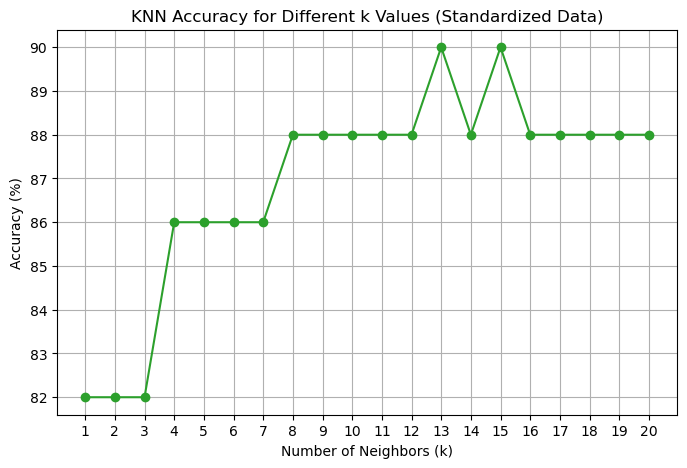


Best k = 13 with Accuracy = 90.00%


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='tab:green')
plt.title("KNN Accuracy for Different k Values (Standardized Data)")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy (%)")
plt.xticks(k_values)
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f"\nBest k = {best_k} with Accuracy = {best_acc:.2f}%")

## Conclusion

From the above results, we observe that all models perform reasonably well, achieving accuracies above 85%.
The Random Forest classifier and Quadratic Discriminant Analysis model achieved the highest hold-out accuracy of 0.92 with the lowest MCE (0.08), indicating strong predictive performance and good generalization.
Logistic Regression (both sklearn and our from-scratch implementation) achieved comparable accuracies (~0.91), validating the correctness of our manual implementation.

Cross-validation results show slightly lower accuracies (≈0.86–0.88), which is expected due to the pessimistic bias introduced by averaging across multiple folds, as explained in the lecture slides (Bias–Variance section).

Overall, Random Forest, Quadratic Discriminant Analysis and Logistic Regression provide the best balance between bias and variance for this dataset, while more complex models like Decision Trees show higher variance, and simpler models like Naive Bayes perform competitively but slightly below the top models.

## Linear Discriminant Analysis

In [ ]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [ ]:
# LDA parameters (binary only)

# class labels
classes = [0, 1]

# class priors
pi0 = np.mean(y_train == 0)
pi1 = np.mean(y_train == 1)

# class means
mu0 = X_train_scaled[y_train == 0].mean(axis=0)
mu1 = X_train_scaled[y_train == 1].mean(axis=0)

# pooled covariance
n0 = np.sum(y_train == 0)
n1 = np.sum(y_train == 1)

S0 = np.cov(X_train_scaled[y_train == 0].T, bias=False)
S1 = np.cov(X_train_scaled[y_train == 1].T, bias=False)

# pooled covariance = weighted sum
Sp = ((n0 - 1) * S0 + (n1 - 1) * S1) / (n0 + n1 - 2)

# regularize for stability
reg = 1e-6
Sp_reg = Sp + reg * np.eye(Sp.shape[0])

# inverse covariance
Sp_inv = np.linalg.pinv(Sp_reg)

print("Means shapes:", mu0.shape, mu1.shape)



Means shapes: (7,) (7,)


In [ ]:
# Linear discriminant score g_k(x):
#   g_k(x) = x^T Σ^{-1} μ_k - 0.5 μ_k^T Σ^{-1} μ_k + log π_k

def g0(x):
    return x @ (Sp_inv @ mu0) - 0.5 * (mu0 @ Sp_inv @ mu0) + np.log(pi0)

def g1(x):
    return x @ (Sp_inv @ mu1) - 0.5 * (mu1 @ Sp_inv @ mu1) + np.log(pi1)

def lda_predict(X):
    scores0 = np.apply_along_axis(g0, 1, X)
    scores1 = np.apply_along_axis(g1, 1, X)
    return (scores1 > scores0).astype(int)

def lda_predict_proba(X):
    scores0 = np.apply_along_axis(g0, 1, X)
    scores1 = np.apply_along_axis(g1, 1, X)
    # stable softmax
    max_scores = np.maximum(scores0, scores1)
    exp0 = np.exp(scores0 - max_scores)
    exp1 = np.exp(scores1 - max_scores)
    p1 = exp1 / (exp0 + exp1)
    return p1

In [ ]:
y_pred = lda_predict(X_test_scaled)
p1 = lda_predict_proba(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, p1)
print("ROC AUC:", auc)


Accuracy: 0.96

Confusion matrix:
 [[27  1]
 [ 1 21]]

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        28
           1       0.95      0.95      0.95        22

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50

ROC AUC: 0.9967532467532467


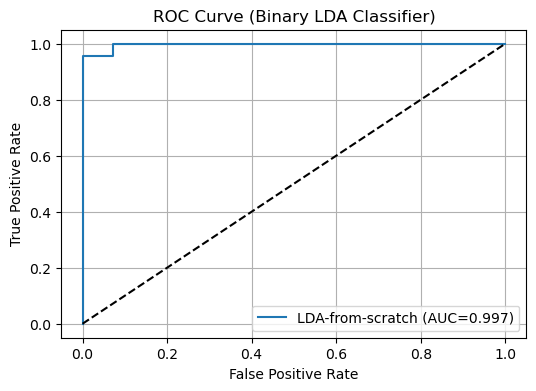

In [ ]:
fpr, tpr, _ = roc_curve(y_test, p1)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"LDA-from-scratch (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Binary LDA Classifier)")
plt.grid(True)
plt.legend()
plt.show()


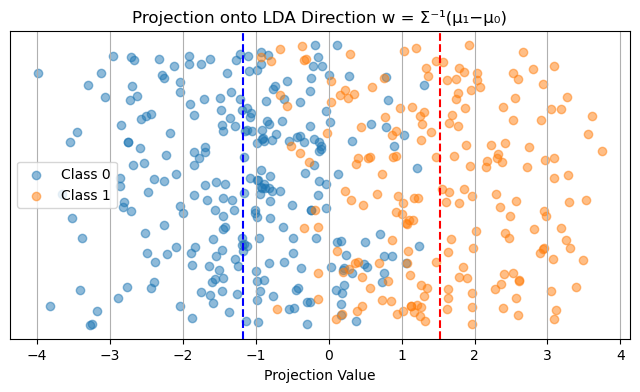

In [ ]:
# LDA direction for binary class (Fisher): w = Σ^{-1} (mu1 - mu0)
w = Sp_inv @ (mu1 - mu0)
w = w / np.linalg.norm(w)

proj_train = X_train_scaled @ w
proj_test = X_test_scaled @ w

plt.figure(figsize=(8,4))
jitter = (np.random.rand(len(proj_train)) - 0.5) * 0.05
plt.scatter(proj_train[y_train==0], jitter[y_train==0], label="Class 0", alpha=0.5)
plt.scatter(proj_train[y_train==1], jitter[y_train==1], label="Class 1", alpha=0.5)

plt.axvline(proj_train[y_train==0].mean(), linestyle='--', color='blue')
plt.axvline(proj_train[y_train==1].mean(), linestyle='--', color='red')

plt.title("Projection onto LDA Direction w = Σ⁻¹(μ₁−μ₀)")
plt.xlabel("Projection Value")
plt.yticks([])
plt.legend()
plt.grid(True)
plt.show()